In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Display all the columns of the dataframe
# pd.pandas.set_option('display.max_columns',None)

In [6]:
dataset = pd.read_csv("dataset/housing in california.csv")

print(dataset.shape)
dataset.head(5)


(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


## Handling Missing Values

In [7]:
features_with_na = [features for features in dataset.columns if dataset[features].isnull().sum()>1]
for feature in features_with_na:
    print(feature,np.round(dataset[feature].isnull().mean(),4),'% data kosong')

total_bedrooms 0.01 % data kosong


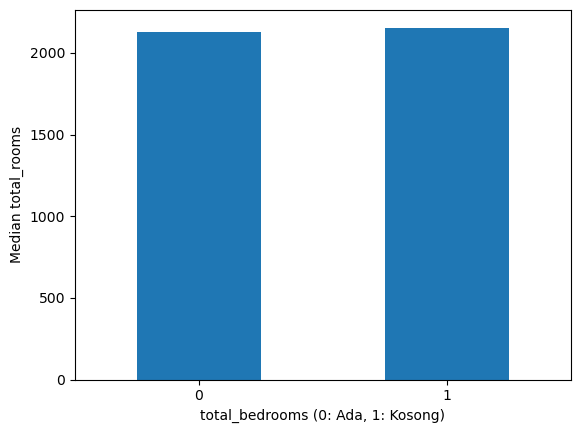

In [9]:
for feature in features_with_na:
    data = dataset.copy()
    data[feature] = np.where(data[feature].isnull(),1,0)

    data.groupby(feature)['total_rooms'].median().plot.bar()
    plt.xlabel(f"{feature} (0: Ada, 1: Kosong)")
    plt.ylabel("Median total_rooms")
    plt.xticks(rotation=0)
    plt.show()

## memiliah colom numerik dan kategorib

### memilih feature angka

In [12]:
numerical_features = [feature for feature in dataset.columns if dataset[feature].dtypes != "O"]

print("Number of numerical variabels: ",len(numerical_features))

dataset[numerical_features].head()

Number of numerical variabels:  9


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200


### memilih feature waktu /datetime

In [14]:
year_feature = [feature for feature in numerical_features if 'Yr' in feature or 'Year' in feature]
year_feature
# tidak ada feature waktu

[]

Text(0.5, 1.0, 'population vs Median house value')

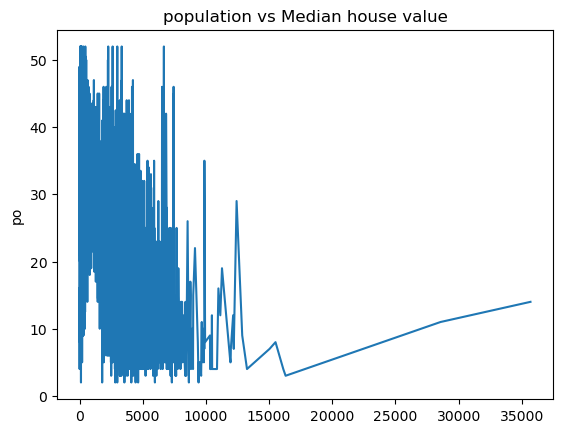